For Summary: [click here](#here)

# Code
<a id='there'></a>

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df = pd.read_csv('../data/pakwheels_data.csv')
df.head()

,name,brand,model,mileage_km,fuel_type,transmission,engine_cc,city,price_pkr
0,Toyota Surf 1997 for Sale,Toyota,1997,100000,Petrol,Automatic,2700,Gujrat,4100000
1,Suzuki Jimny 1991 for Sale,Suzuki,1991,130000,Petrol,Manual,1000,Gujrat,1100000
2,Honda City 2004 i-DSI Vario for Sale,Honda,2004,250000,Petrol,Automatic,1300,Lahore,1825000
3,Honda City 2005 i-DSI for Sale,Honda,2005,250000,Petrol,Manual,1300,Lahore,1625000
4,Toyota IST 2003 1.3 A for Sale,Toyota,2003,100000,Petrol,Automatic,1300,Karachi,1500000


In [5]:
df.shape

(26404, 9)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
model,26404.0,2.003488e+03,7.029950e+00,1940.0,2001.0,2006.0,2008.0,2011.0
mileage_km,26404.0,1.445195e+05,1.094092e+05,1.0,90000.0,127520.0,185000.0,1000000.0
engine_cc,26404.0,1.469885e+03,8.732855e+02,100.0,1000.0,1300.0,1600.0,15000.0
price_pkr,26404.0,2.271607e+06,2.769062e+06,130000.0,930000.0,1540000.0,2450000.0,40000000.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26404 entries, 0 to 26403
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   name          26404 non-null  object
 1   brand         26404 non-null  object
 2   model         26404 non-null  int64 
 3   mileage_km    26404 non-null  int64 
 4   fuel_type     26404 non-null  object
 5   transmission  26404 non-null  object
 6   engine_cc     26404 non-null  int64 
 7   city          26404 non-null  object
 8   price_pkr     26404 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.8+ MB


In [8]:
df.duplicated().sum()
# df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

1673

In [9]:
df.isnull().sum().sort_values(ascending=False)

name            0
brand           0
model           0
mileage_km      0
fuel_type       0
transmission    0
engine_cc       0
city            0
price_pkr       0
dtype: int64

In [10]:
len(df['brand'].unique())

52

In [11]:
df.corr(numeric_only=True)

,model,mileage_km,engine_cc,price_pkr
model,1.000000,-0.029586,-0.062223,0.207466
mileage_km,-0.029586,1.000000,0.045971,-0.006760
engine_cc,-0.062223,0.045971,1.000000,0.717718
price_pkr,0.207466,-0.006760,0.717718,1.000000


In [12]:
brands = df['brand'].value_counts()
rare_brands = brands[brands.values < 10]

print(len(rare_brands))
# print(rare_brands)

28


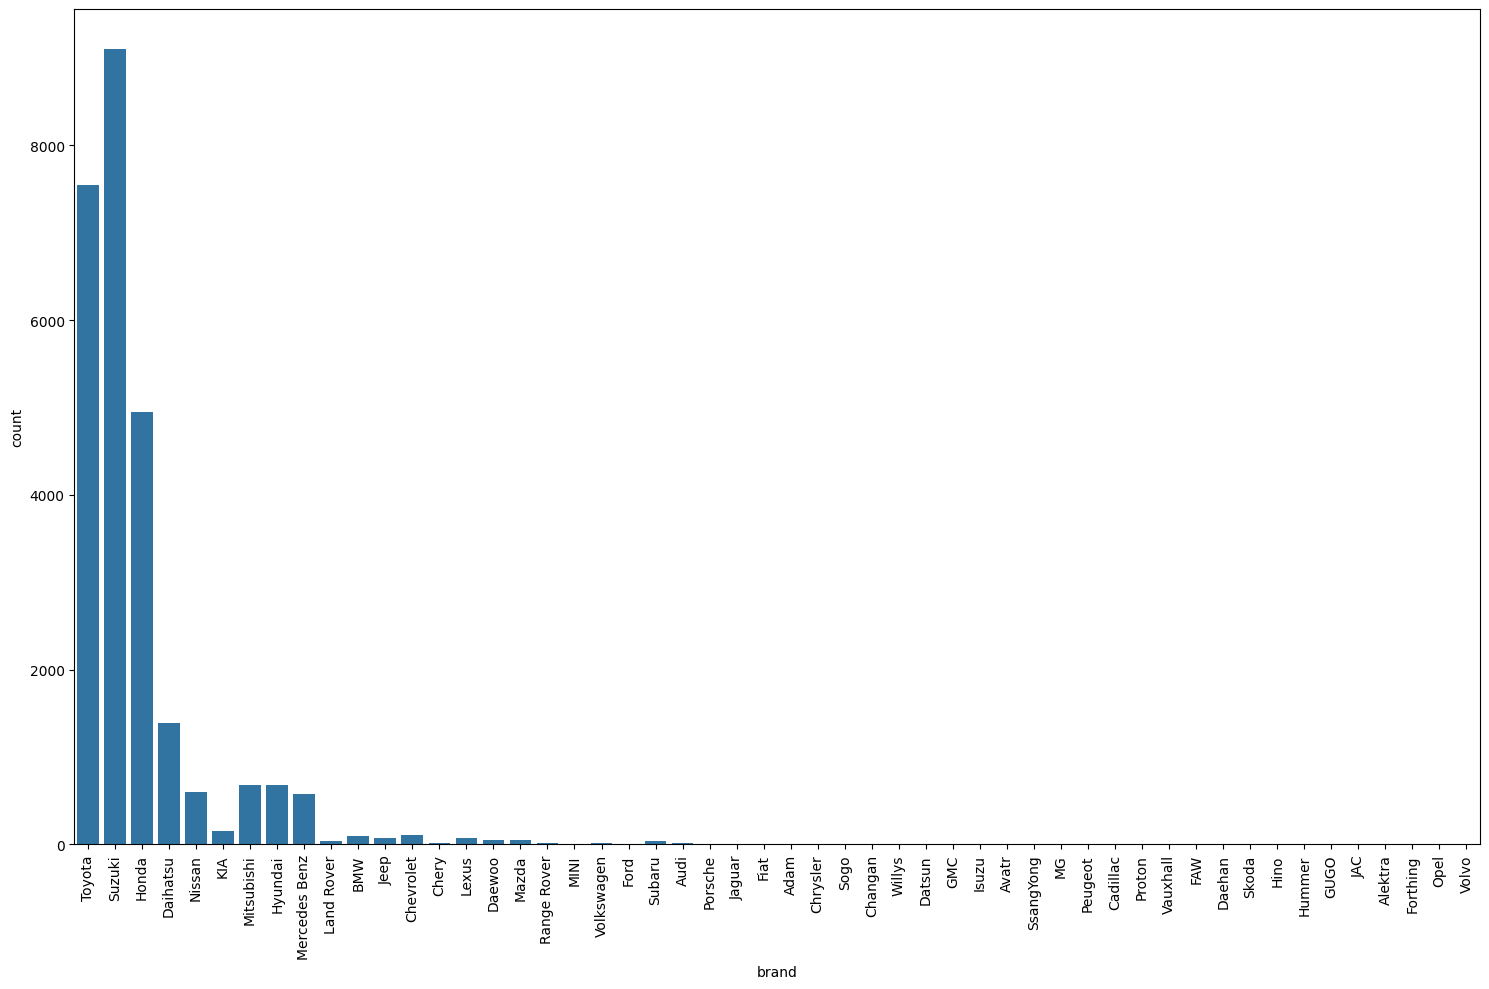

In [13]:
plt.figure(figsize=(15, 10))
sns.countplot(x=df['brand'])
plt.xticks(rotation=90)
plt.tight_layout()

In [14]:
df['brand'].value_counts(normalize=True).head(5)*100

brand
Suzuki        34.483412
Toyota        28.597940
Honda         18.743372
Daihatsu       5.271928
Mitsubishi     2.579155
Name: proportion, dtype: float64

In [15]:
data = df

top_5_brands = df['brand'].value_counts().nlargest(5).index

data['grouped_brands'] = data['brand'].where(df['brand'].isin(top_5_brands), 'Other')

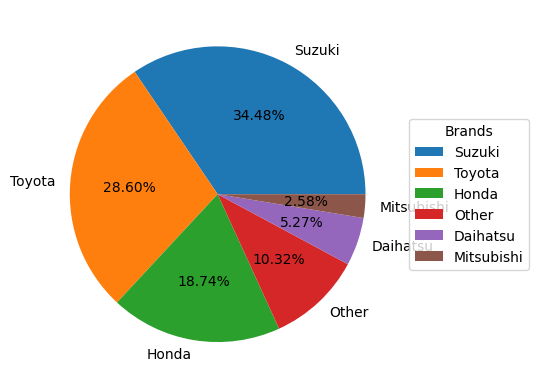

In [16]:
plt.pie(x=data['grouped_brands'].value_counts(), autopct='%.2f%%',
        labels=df['grouped_brands'].value_counts().index)
plt.legend(
    title="Brands", 
    loc="center left", 
    bbox_to_anchor=(1, 0.5)  # Places the legend to the right of the chart
)

In [17]:
len(df['model'].unique())

55

In [18]:
models = df['model'].value_counts()
rare_models = models[models.values <= 250]
common_models = models[models.values > 250]

len(rare_models)

32

<Axes: xlabel='model', ylabel='count'>

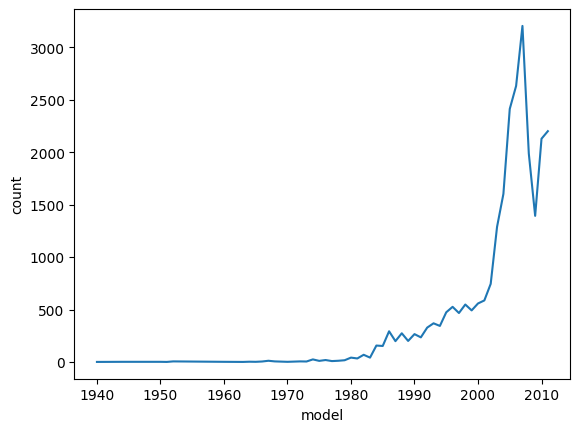

In [19]:
sns.lineplot(models)

<Axes: xlabel='model', ylabel='Count'>

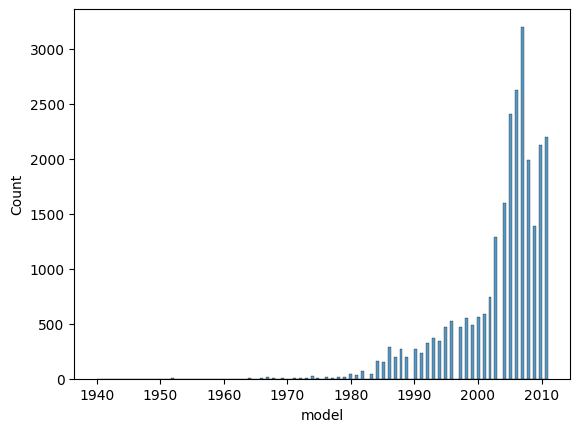

In [20]:
sns.histplot(df['model'])

<Axes: ylabel='model'>

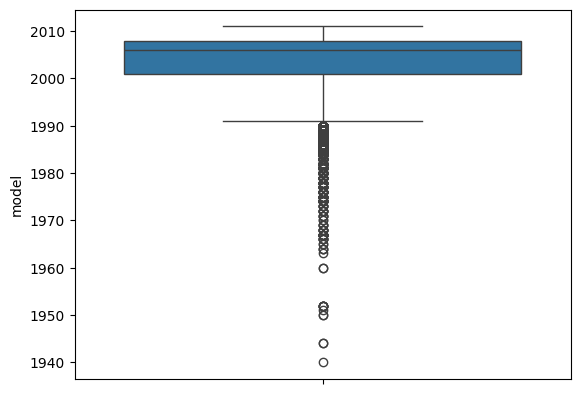

In [21]:
sns.boxplot(df['model'])

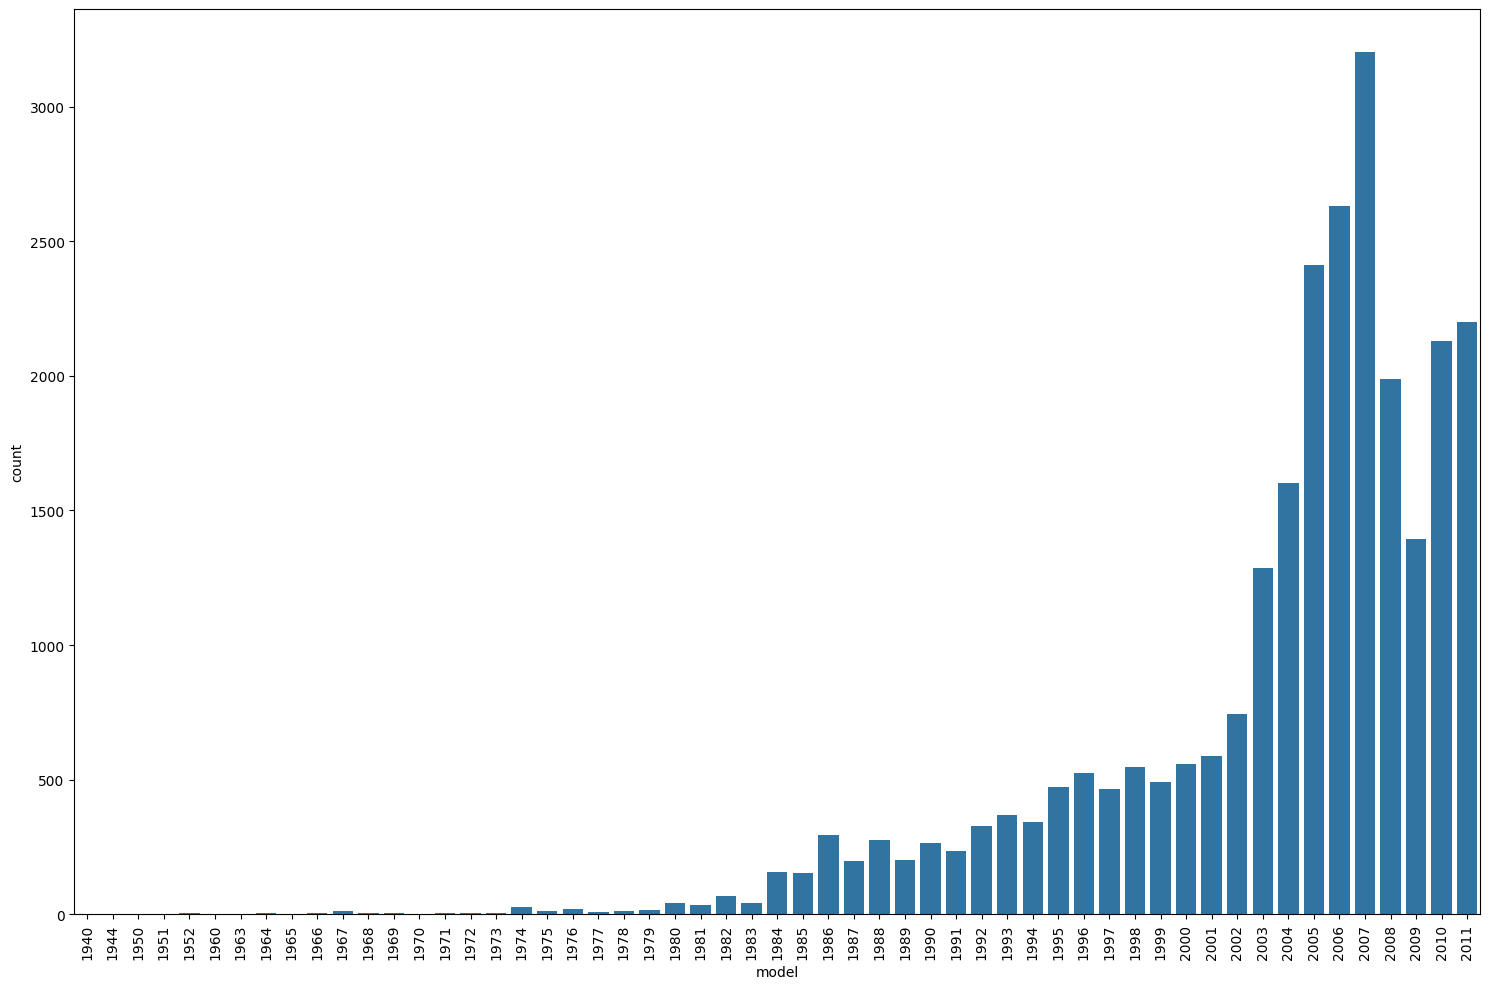

In [22]:
plt.figure(figsize=(15, 10))
sns.countplot(x=df['model'])
plt.xticks(rotation=90)
plt.tight_layout()

In [23]:
df['model'].value_counts(normalize=True).head()*100

model
2007    12.130738
2006     9.964399
2005     9.134980
2011     8.332071
2010     8.059385
Name: proportion, dtype: float64

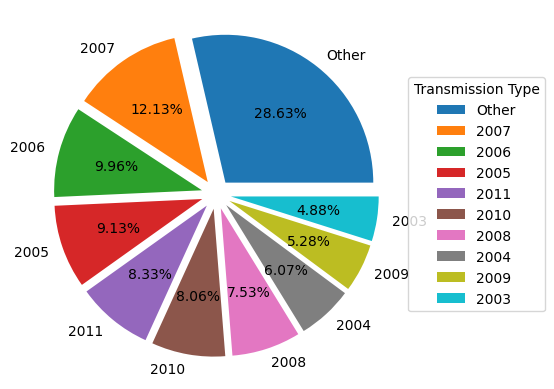

In [24]:
data = df
models = data['model'].value_counts(normalize=True)

top_models = models[models.values > 0.03]
top_models = top_models.index

data['grouped_models'] = data['model'].where(data['model'].isin(top_models), 'Other')

plt.pie(x=data['grouped_models'].value_counts(), autopct='%.2f%%', 
        explode=[0.1]*len(data['grouped_models'].unique()),
        labels=data['grouped_models'].value_counts().index)
plt.legend(
    title="Transmission Type", 
    loc="center left", 
    bbox_to_anchor=(1, 0.5)  # Places the legend to the right of the chart
)

<Axes: xlabel='mileage_km', ylabel='Count'>

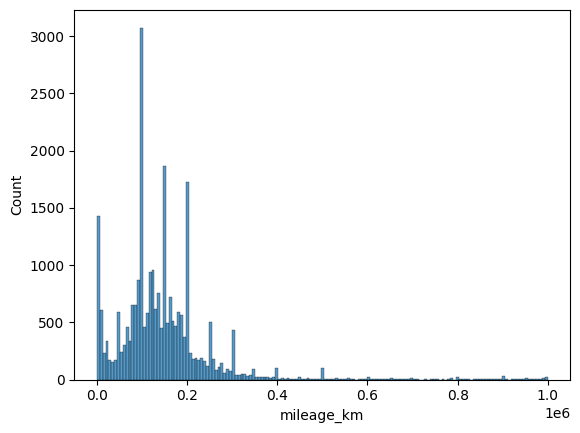

In [25]:
sns.histplot(df['mileage_km'])

In [26]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
model,26404.0,2.003488e+03,7.029950e+00,1940.0,2001.0,2006.0,2008.0,2011.0
mileage_km,26404.0,1.445195e+05,1.094092e+05,1.0,90000.0,127520.0,185000.0,1000000.0
engine_cc,26404.0,1.469885e+03,8.732855e+02,100.0,1000.0,1300.0,1600.0,15000.0
price_pkr,26404.0,2.271607e+06,2.769062e+06,130000.0,930000.0,1540000.0,2450000.0,40000000.0


<Axes: ylabel='mileage_km'>

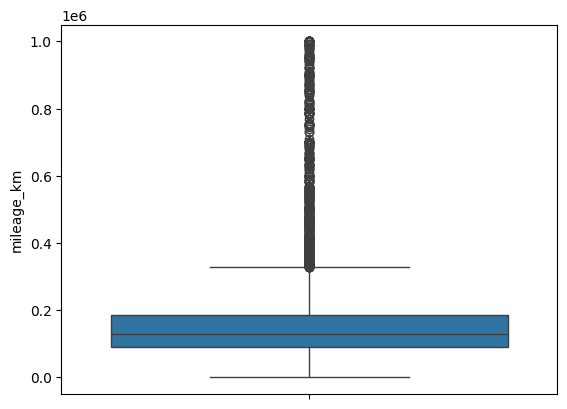

In [27]:
sns.boxplot(df['mileage_km'])

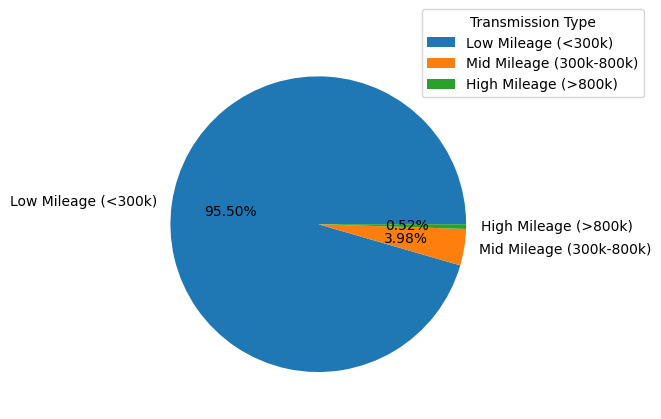

In [28]:
bins = [0, 300000, 800000, float('inf')]
labels = ['Low Mileage (<300k)', 'Mid Mileage (300k-800k)', 'High Mileage (>800k)']

data['mileage_tier'] = pd.cut(data['mileage_km'], bins=bins, labels=labels, include_lowest=True)

plt.pie(x=data['mileage_tier'].value_counts(), autopct='%.2f%%',
        labels=data['mileage_tier'].value_counts().index)
plt.legend(
    title="Transmission Type", 
    loc="upper right", 
    bbox_to_anchor=(1.4, 1.1)  # Places the legend to the right of the chart
)

<Axes: xlabel='fuel_type', ylabel='count'>

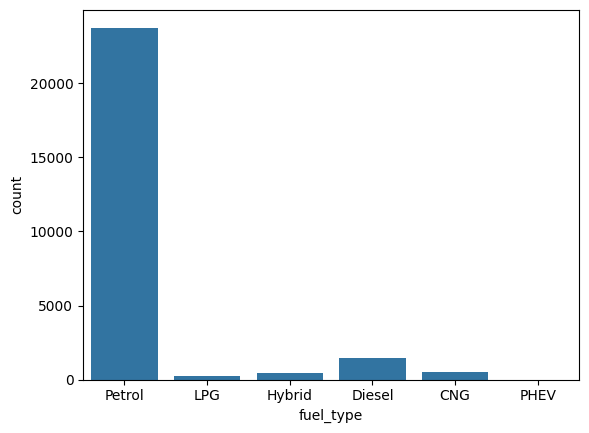

In [29]:
sns.countplot(x=df['fuel_type'])

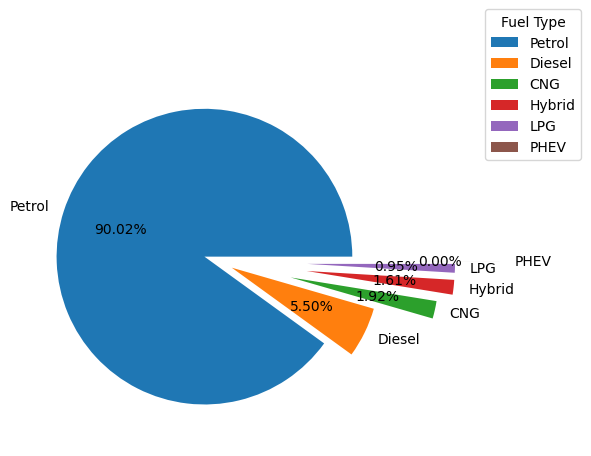

In [30]:
plt.pie(x=df['fuel_type'].value_counts(), autopct='%.2f%%',
        labels=df['fuel_type'].value_counts().index, explode=(0.1, 0.1, 0.5, 0.6, 0.6, 0.9))
plt.legend(title='Fuel Type', loc='upper right', bbox_to_anchor=(1.5, 1.2))

In [31]:
print(df['transmission'].value_counts().index)

Index(['Manual', 'Automatic'], dtype='object', name='transmission')


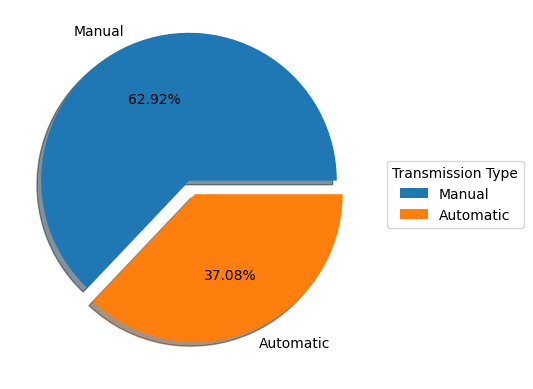

In [32]:
plt.pie(x=df['transmission'].value_counts(), autopct='%.2f%%', explode=(0.1, 0.0), startangle=0, shadow=True,
        labels=df['transmission'].value_counts().index)
plt.legend(
    title="Transmission Type", 
    loc="center left", 
    bbox_to_anchor=(1, 0.5)  # Places the legend to the right of the chart
)

<Axes: xlabel='engine_cc', ylabel='Count'>

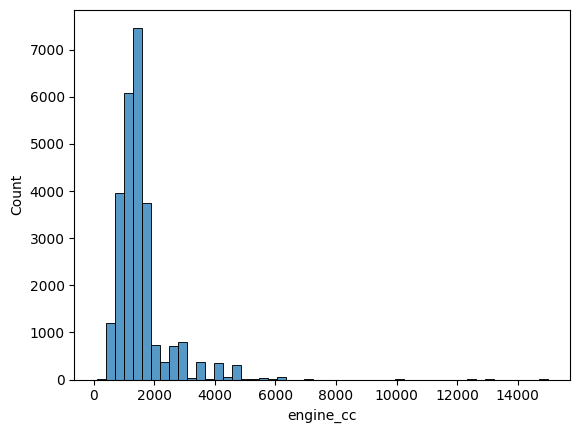

In [33]:
sns.histplot(df['engine_cc'], bins=50)

<Axes: ylabel='engine_cc'>

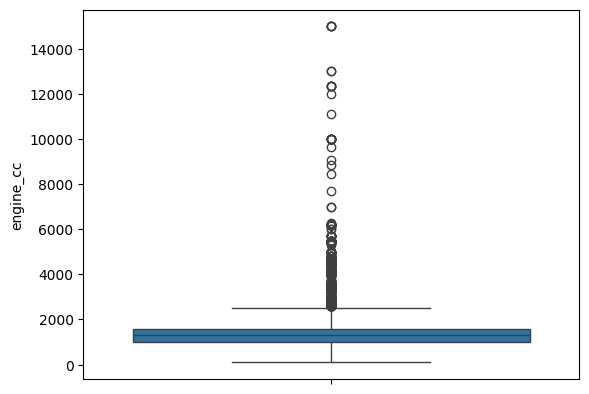

In [34]:
sns.boxplot(df['engine_cc'])

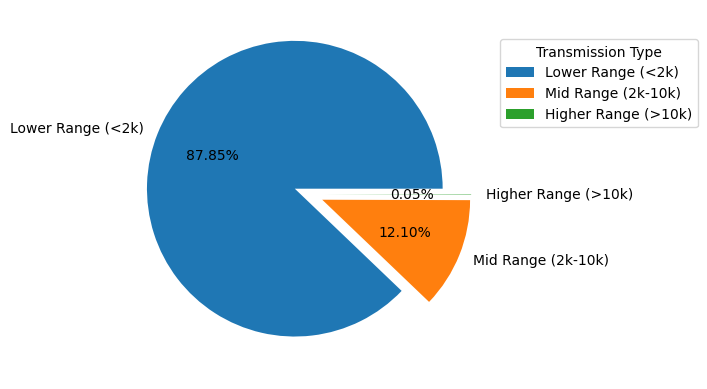

In [35]:
bins = [0, 2000, 10000, float('inf')]
labels = ['Lower Range (<2k)', 'Mid Range (2k-10k)', 'Higher Range (>10k)']

data['grouped_engines'] = pd.cut(df['engine_cc'], bins=bins, labels=labels, include_lowest=True)

plt.pie(x=data['grouped_engines'].value_counts(), autopct='%.2f%%',
        explode=[0.1]*len(data['grouped_engines'].unique()),
        labels=data['grouped_engines'].value_counts().index)
plt.legend(
    title="Transmission Type", 
    loc="center left", 
    bbox_to_anchor=(1, 0.8)  # Places the legend to the right of the chart
)

In [36]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
model,26404.0,2.003488e+03,7.029950e+00,1940.0,2001.0,2006.0,2008.0,2011.0
mileage_km,26404.0,1.445195e+05,1.094092e+05,1.0,90000.0,127520.0,185000.0,1000000.0
engine_cc,26404.0,1.469885e+03,8.732855e+02,100.0,1000.0,1300.0,1600.0,15000.0
price_pkr,26404.0,2.271607e+06,2.769062e+06,130000.0,930000.0,1540000.0,2450000.0,40000000.0


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  124,
  125,
  126,
  127,
  128,
  129,
  130,
  131,
  132,
  133,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  141,
  142,
  143,
  144,
  145,
  146,
  147,
  148,
  149,
  150,
  151,
  152,
  153,
  154,
  155,
  156,
  157,
  15

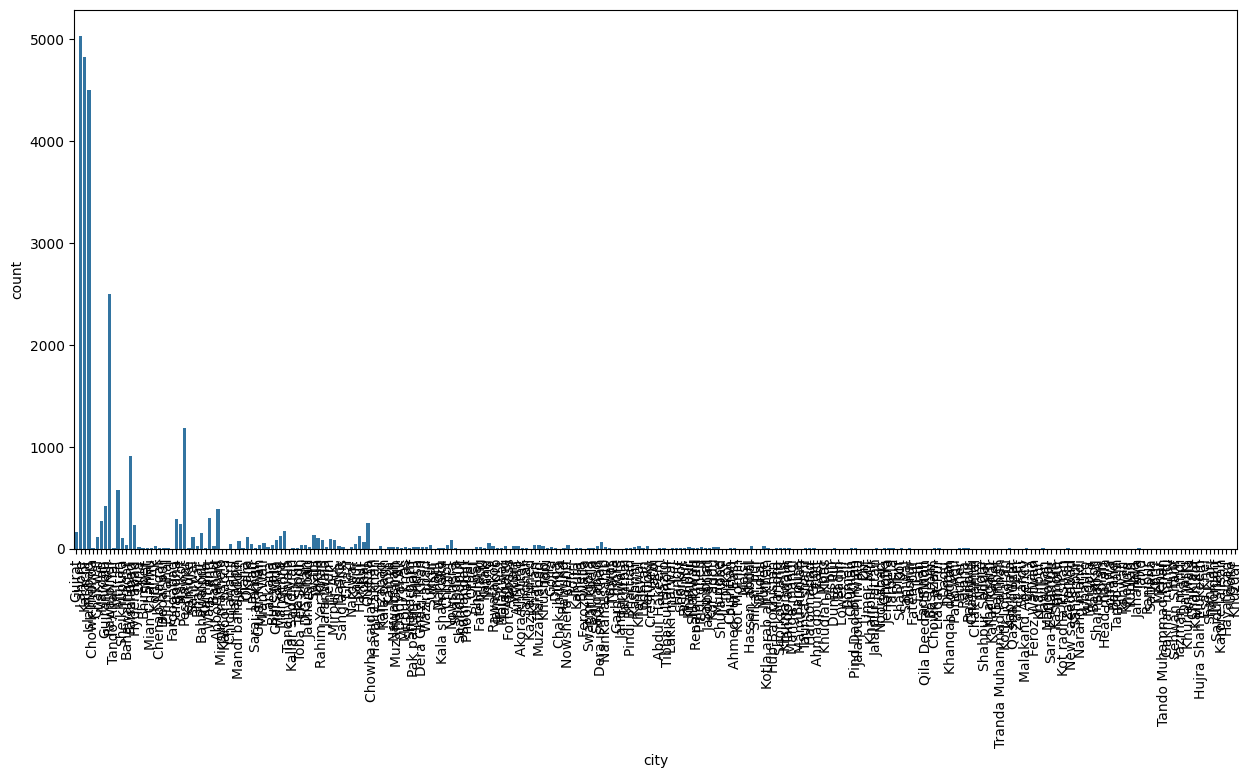

In [37]:
plt.figure(figsize=(15, 7))
sns.countplot(x=df['city'])
plt.xticks(rotation=90)

In [38]:
len(df['city'].unique())

279

In [39]:
top_cities = df['city'].value_counts().head(20).index
top_cities

Index(['Lahore', 'Karachi', 'Islamabad', 'Rawalpindi', 'Peshawar',
       'Faisalabad', 'Multan', 'Gujranwala', 'Abbottabad', 'Wah cantt',
       'Sargodha', 'Mardan', 'Quetta', 'Sialkot', 'Hyderabad', 'Attock',
       'Gujrat', 'Bahawalpur', 'Swabi', 'Haripur'],
      dtype='object', name='city')

C:\Users\hamza\AppData\Local\Temp\ipykernel_3488\3023152681.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['city'].isin(top_cities)], x='city', order=top_cities, palette='pastel')


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'Lahore'),
  Text(1, 0, 'Karachi'),
  Text(2, 0, 'Islamabad'),
  Text(3, 0, 'Rawalpindi'),
  Text(4, 0, 'Peshawar'),
  Text(5, 0, 'Faisalabad'),
  Text(6, 0, 'Multan'),
  Text(7, 0, 'Gujranwala'),
  Text(8, 0, 'Abbottabad'),
  Text(9, 0, 'Wah cantt'),
  Text(10, 0, 'Sargodha'),
  Text(11, 0, 'Mardan'),
  Text(12, 0, 'Quetta'),
  Text(13, 0, 'Sialkot'),
  Text(14, 0, 'Hyderabad'),
  Text(15, 0, 'Attock'),
  Text(16, 0, 'Gujrat'),
  Text(17, 0, 'Bahawalpur'),
  Text(18, 0, 'Swabi'),
  Text(19, 0, 'Haripur')])

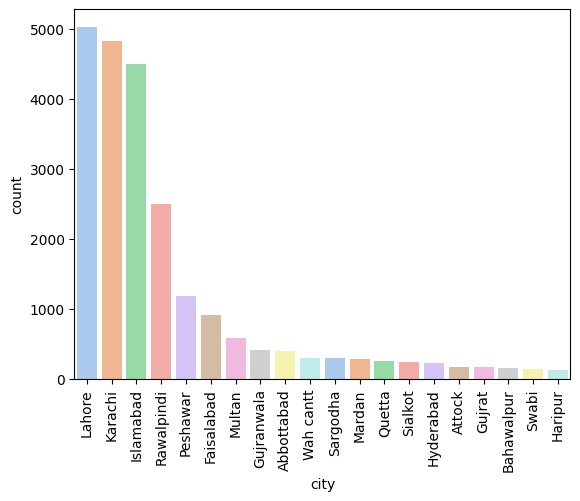

In [40]:
sns.countplot(data=df[df['city'].isin(top_cities)], x='city', order=top_cities, palette='pastel')
plt.xticks(rotation=90)

<Axes: xlabel='price_pkr', ylabel='Count'>

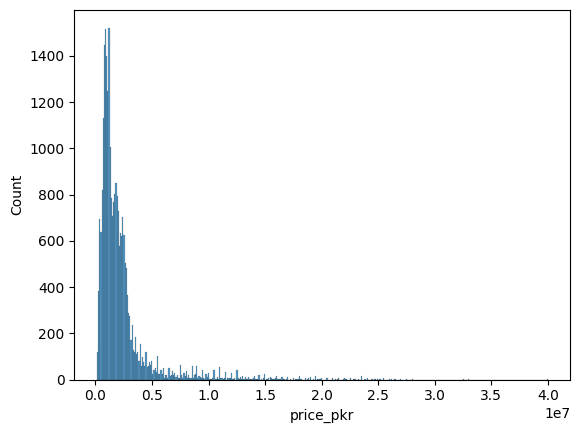

In [41]:
sns.histplot(df['price_pkr'])

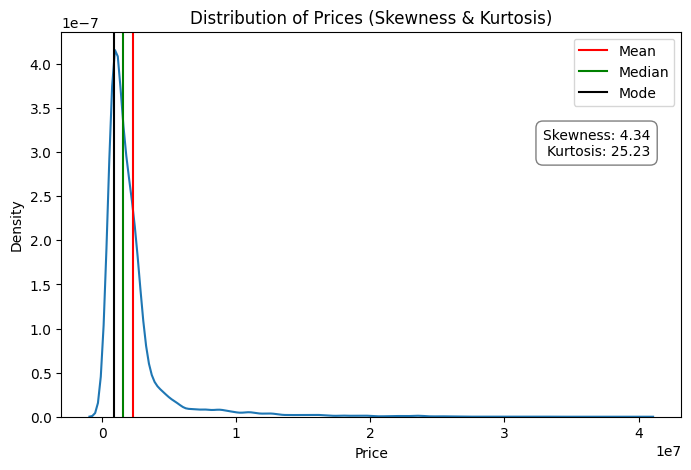

In [42]:
skew = df['price_pkr'].skew()
kurtosis = df['price_pkr'].kurtosis()

mean = df['price_pkr'].mean()
median = df['price_pkr'].median()
mode = df['price_pkr'].mode()

plt.figure(figsize=(8, 5))
sns.kdeplot(df['price_pkr'])
plt.axvline(mean, color='red', label="Mean")
plt.axvline(median, color='green', label="Median")
plt.axvline(mode.squeeze(), color='black', label="Mode")

textstr = f"Skewness: {skew:.2f}\nKurtosis: {kurtosis:.2f}"
plt.text(0.95, 0.75, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.5))

plt.title("Distribution of Prices (Skewness & Kurtosis)")
plt.xlabel("Price")
plt.legend()
plt.show()


In [43]:
df['price_pkr'].median()

1540000.0

In [44]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
model,26404.0,2.003488e+03,7.029950e+00,1940.0,2001.0,2006.0,2008.0,2011.0
mileage_km,26404.0,1.445195e+05,1.094092e+05,1.0,90000.0,127520.0,185000.0,1000000.0
engine_cc,26404.0,1.469885e+03,8.732855e+02,100.0,1000.0,1300.0,1600.0,15000.0
price_pkr,26404.0,2.271607e+06,2.769062e+06,130000.0,930000.0,1540000.0,2450000.0,40000000.0


<Axes: ylabel='price_pkr'>

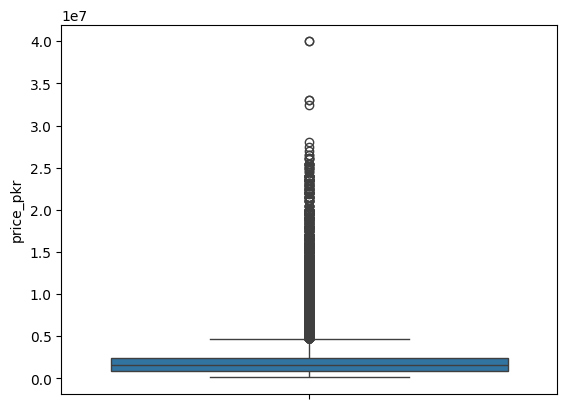

In [45]:
sns.boxplot(df['price_pkr'])

In [46]:
df['price_pkr'].min()

130000

In [47]:
df['price_pkr'].mean()

2271606.5584381153

In [48]:
df['price_pkr'].max()

40000000

<a id='here'></a>
# Summary
## What is this data about and what problem are we trying to solve?

This is PakWheels' dataset, scraped in June 2026. It was scraped to train a model that can predict the prices of used cars in Pakistan.

- **Data size:** (26404, 9)
- **Duplicate rows:** 1673
- **Missing values:** 0
- **Data anomalies:** 0
- **Data types of attributes:** int64 (4 cols), object (5 cols)
- **Mathematical representation of data:** `df.describe()`

## Univariate Analysis

### Brand (Categorical)
- There are a total of 52 brands.
- Most of the cars belong to **Toyota** (34.48%), **Suzuki** (28.59%) and **Honda** (18.74%).
- 28 out of 52 brands have less than 10 records.
- Overall positively skewed.

### City (Categorical)
- There are 279 different categories (high cardinality problem).
- We plot only the top 20 cities, which shows most of the cars are from **Lahore**, **Karachi** & **Islamabad**.
- The remaining 250+ cities contain a small number of listings, causing a long-tail distribution.
- Overall positively skewed.

### Model (Categorical)
- Negatively skewed.
- The highest chunk of the data belongs to model **2007** (12.13%).
- Out of 55 models, 32 contain less than 250 rows.

### Fuel_Type (Categorical)
- Mostly cars are petrol (90.02%).

### Transmission (Categorical)
- 62.92% cars are manual while 37.08% are automatic.

### Engine_cc (Numerical)
- Data ranges from 100–15k cc.
- 87.85% of data is below 2k.
- 12.10% is between 2k–10k.
- 0.05% is above 10k.
- Heavily right skewed.
- So many outliers.

### Mileage_kms (Numerical)
- Data ranges from 100k–1M kms.
- 95.5% of data is below 300k.
- 3.98% is between 300k–800k.
- 0.52% is above 800k.
- Heavily right skewed.
- So many outliers.

### Price_pkr (Numerical)
- Data range: 130k – 40M.
- Heavily positive skewed (Skewness = 4.34).
- Sharp and tall peak (leptokurtic — 25.23).
- So many outliers.

### Central Tendency
- See `df.describe()`.

For code: [click here](#there)